In [220]:
import mysql.connector
import pandas as pd
import matplotlib.pyplot as plt

conn = mysql.connector.connect(
    host="35.199.115.174",
    user="looqbox-challenge",
    password="looq-challenge",
    database="looqbox-challenge"
)

query = """
SELECT
    Title,
    Genre,
    Director,
    Actors,
    Year,
    Runtime,
    Rating,
    Votes,
    RevenueMillions,
    Metascore
FROM IMDB_movies
"""

df = pd.read_sql(query, conn)

conn.close()
display(df)

C:\Users\leandromenali\AppData\Local\Temp\ipykernel_24328\1374373091.py:27: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


,Title,Genre,Director,Actors,Year,Runtime,Rating,Votes,RevenueMillions,Metascore
0,Guardians of the Galaxy,"Action,Adventure,Sci-Fi",James Gunn,"Chris Pratt, Vin Diesel, Bradley Cooper, Zoe S...",2014,121,8.0,757074,333.0,76.0
1,Prometheus,"Adventure,Mystery,Sci-Fi",Ridley Scott,"Noomi Rapace, Logan Marshall-Green, Michael Fa...",2012,124,7.0,485820,126.0,65.0
2,Split,"Horror,Thriller",M. Night Shyamalan,"James McAvoy, Anya Taylor-Joy, Haley Lu Richar...",2016,117,7.0,157606,138.0,62.0
3,Sing,"Animation,Comedy,Family",Christophe Lourdelet,"Matthew McConaughey,Reese Witherspoon, Seth Ma...",2016,108,7.0,60545,270.0,59.0
4,Suicide Squad,"Action,Adventure,Fantasy",David Ayer,"Will Smith, Jared Leto, Margot Robbie, Viola D...",2016,123,6.0,393727,325.0,40.0
...,...,...,...,...,...,...,...,...,...,...
995,Secret in Their Eyes,"Crime,Drama,Mystery",Billy Ray,"Chiwetel Ejiofor, Nicole Kidman, Julia Roberts...",2015,111,6.0,27585,NaN,45.0
996,Hostel: Part II,Horror,Eli Roth,"Lauren German, Heather Matarazzo, Bijou Philli...",2007,94,6.0,73152,18.0,46.0
997,Step Up 2: The Streets,"Drama,Music,Romance",Jon M. Chu,"Robert Hoffman, Briana Evigan, Cassie Ventura,...",2008,98,6.0,70699,58.0,50.0
998,Search Party,"Adventure,Comedy",Scot Armstrong,"Adam Pally, T.J. Miller, Thomas Middleditch,Sh...",2014,93,6.0,4881,NaN,22.0


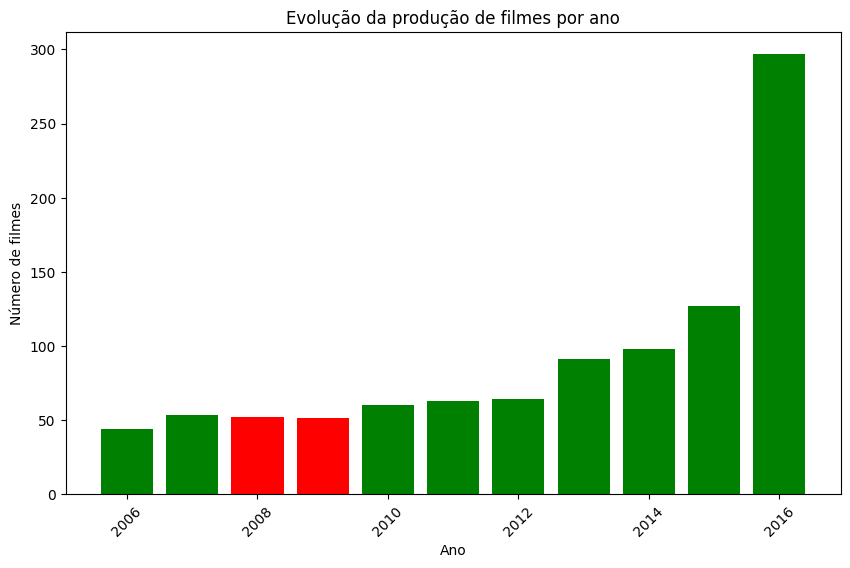

In [221]:
df_count = df.groupby("Year").size().reset_index(name="Movies_Count")
df_count = df_count.sort_values("Year")
df_count["diff"] = df_count["Movies_Count"].diff()
colors = df_count["diff"].apply(
    lambda x: "green" if pd.isna(x) else ("green" if x >= 0 else "red")
)

plt.figure(figsize=(10,6))

plt.bar(df_count["Year"], df_count["Movies_Count"], color=colors)

plt.title("Evolução da produção de filmes por ano")
plt.xlabel("Ano")
plt.ylabel("Número de filmes")

plt.xticks(rotation=45)

plt.show()

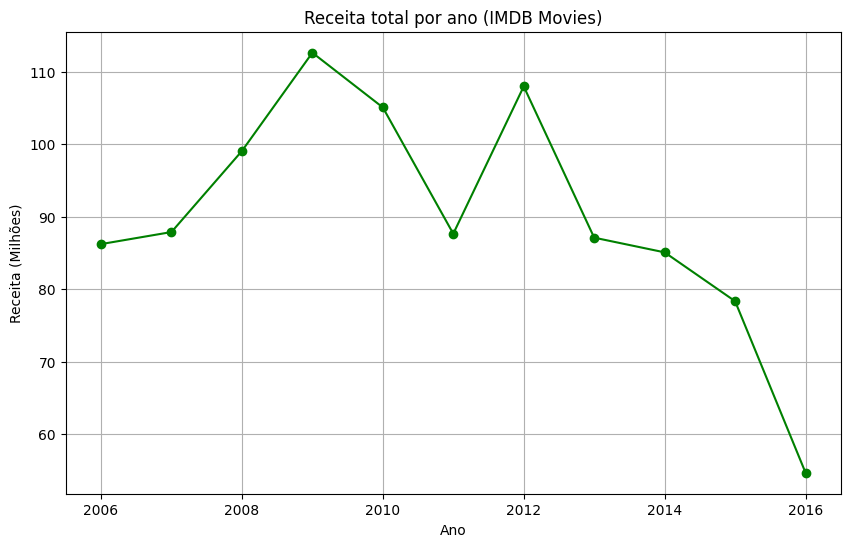

In [ ]:
df_year = df.groupby("Year")["RevenueMillions"].mean().reset_index()
df_year = df_year.sort_values("Year")

plt.figure(figsize=(10,6))

plt.plot(df_year["Year"], df_year["RevenueMillions"], marker="o", color="g")

plt.title("Receita média por ano (IMDB Movies)")
plt.xlabel("Ano")
plt.ylabel("Receita (Milhões)")

plt.grid(True)

plt.show()


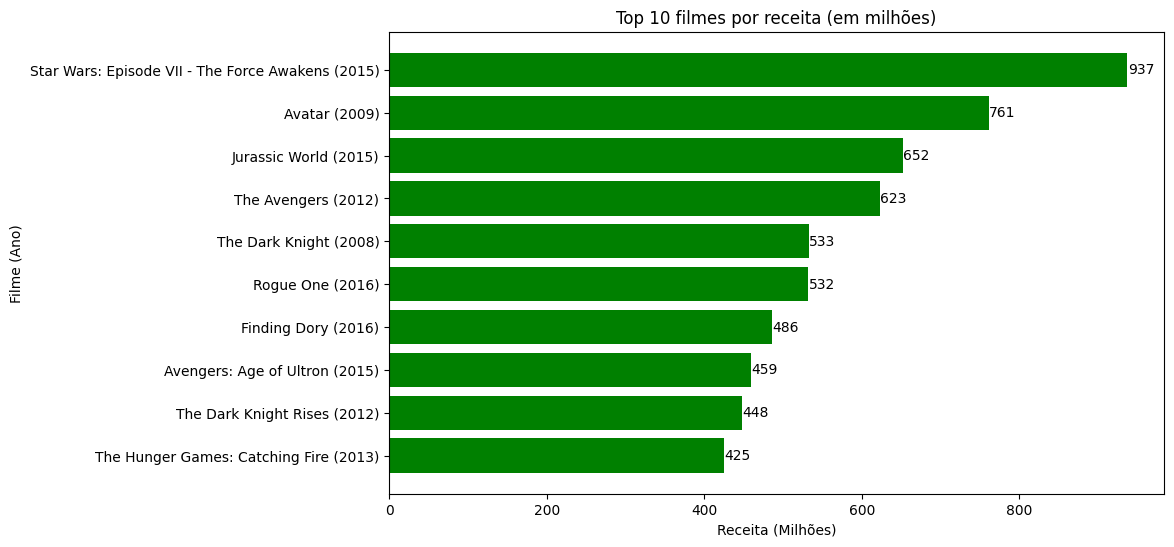

In [223]:
df["RevenueMillions"] = pd.to_numeric(df["RevenueMillions"], errors="coerce")

df = df.dropna(subset=["RevenueMillions", "Title", "Year"])
top10 = df.sort_values("RevenueMillions", ascending=False).head(10).copy()
top10["label"] = top10["Title"] + " (" + top10["Year"].astype(int).astype(str) + ")"

plt.figure(figsize=(10,6))
bars = plt.barh(
    top10["label"],
    top10["RevenueMillions"],
    color="green"
)
plt.title("Top 10 filmes por receita (em milhões)")
plt.xlabel("Receita (Milhões)")
plt.ylabel("Filme (Ano)")

plt.gca().invert_yaxis()

# valores nas barras
for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.5,
        bar.get_y() + bar.get_height()/2,
        f"{width:.0f}",
        va="center"
    )

plt.show()

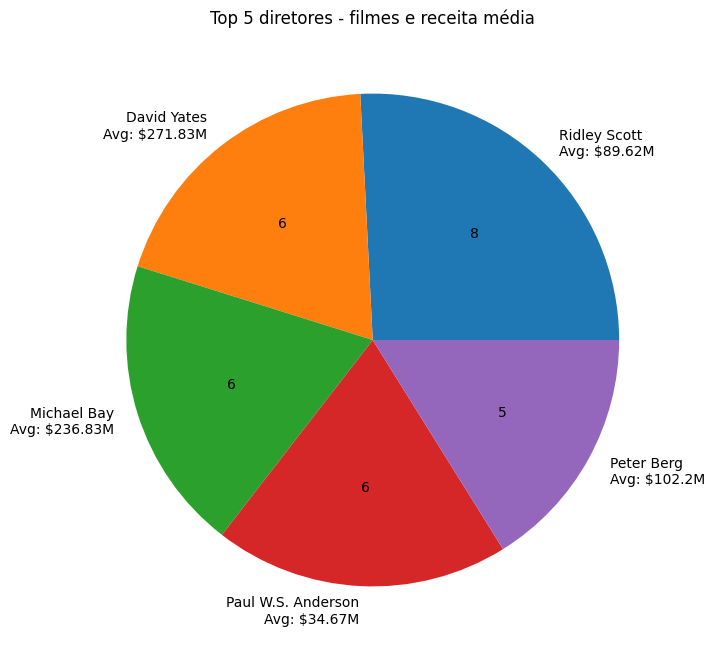

In [224]:
top_directors = (
    df.groupby("Director")
    .size()
    .reset_index(name="movies_count")
    .sort_values("movies_count", ascending=False)
    .head(5)
)

director_revenue = (
    df.groupby("Director")["RevenueMillions"]
    .mean()
    .reset_index(name="avg_revenue")
)

top_directors = top_directors.merge(director_revenue, on="Director", how="left")
top_directors["label"] = (
    top_directors["Director"] +
    "\nAvg: $" +
    top_directors["avg_revenue"].round(2).astype(str) +
    "M"
)

plt.figure(figsize=(8,8))

plt.pie(
    top_directors["movies_count"],
    labels=top_directors["label"],
    autopct=lambda p: f'{int(round(p * top_directors["movies_count"].sum() / 100))}'
)

plt.title("Top 5 diretores - filmes e receita média")
plt.show()

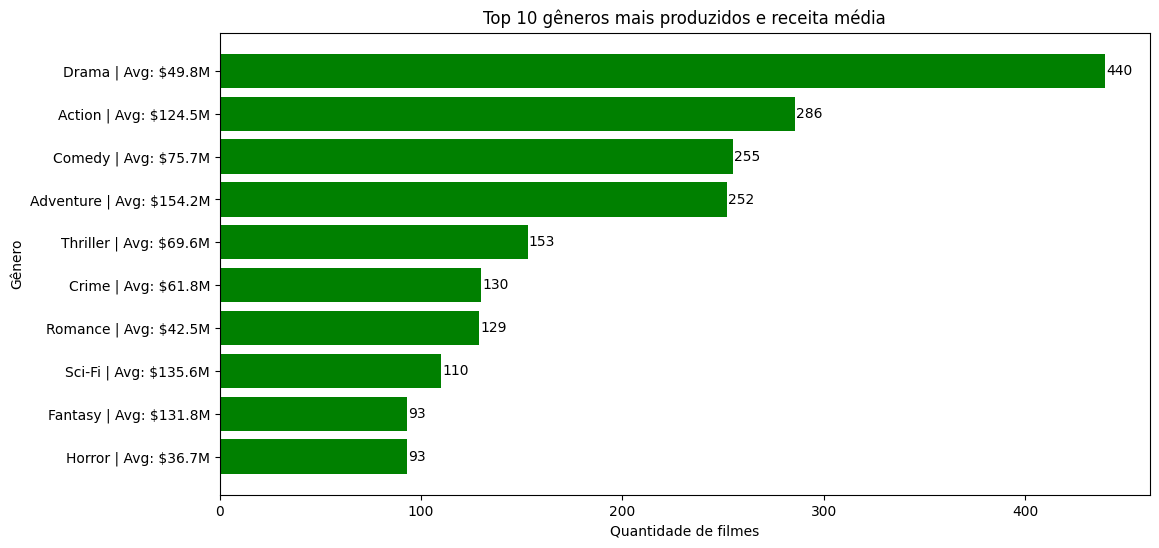

In [225]:
df["Genre"] = df["Genre"].astype(str).str.strip()
df["Genre"] = df["Genre"].str.split(r"\s*,\s*")
df_exploded = df.explode("Genre")
df_exploded["Genre"] = df_exploded["Genre"].str.strip()
#display(df_exploded)

genre_count = (
    df_exploded["Genre"]
    .value_counts()
    .reset_index()
)

genre_count.columns = ["Genre", "Count"]
#display(genre_count)

genre_revenue = (
    df_exploded.groupby("Genre")["RevenueMillions"]
    .mean()
    .reset_index(name="Avg_Revenue")
)

genre_summary = genre_count.merge(
    genre_revenue,
    on="Genre",
    how="left"
)


top_genres = genre_summary.head(10).copy()

top_genres["label"] = (
    top_genres["Genre"] +
    " | Avg: $" +
    top_genres["Avg_Revenue"].round(1).astype(str) +
    "M"
)
plt.figure(figsize=(12,6))

bars = plt.barh(
    top_genres["label"],
    top_genres["Count"],
    color="g"
)

plt.title("Top 10 gêneros mais produzidos e receita média")
plt.xlabel("Quantidade de filmes")
plt.ylabel("Gênero")

plt.gca().invert_yaxis()  

for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.5,              
        bar.get_y() + bar.get_height()/2, 
        int(width),               
        va="center"
    )

plt.show()


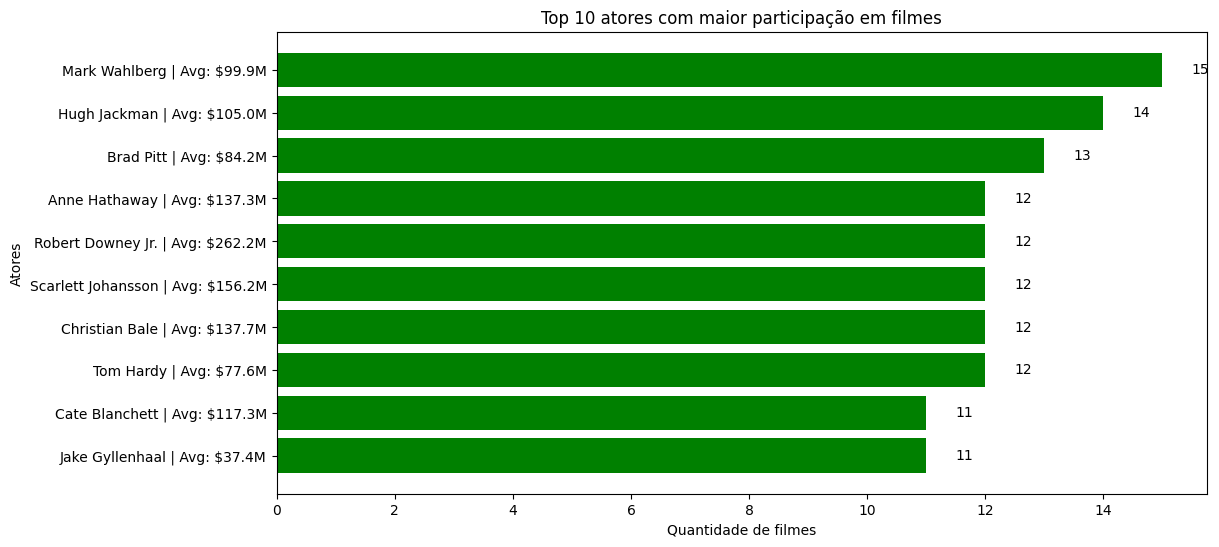

In [226]:
df["Actors"] = df["Actors"].astype(str).str.strip()
df["Actors"] = df["Actors"].str.split(r"\s*,\s*")
df_exploded = df.explode("Actors")
df_exploded["Actors"] = df_exploded["Actors"].str.strip()
#display(df_exploded)

actors_count = (
    df_exploded["Actors"]
    .value_counts()
    .reset_index()
)

actors_count.columns = ["Actors", "Count"]

actors_revenue = (
    df_exploded.groupby("Actors")["RevenueMillions"]
    .mean()
    .reset_index(name="Avg_Revenue")
)

actors_summary = actors_count.merge(
    actors_revenue,
    on="Actors",
    how="left"
)

top_actors = actors_summary.head(10).copy()
top_actors["label"] = (
    top_actors["Actors"] +
    " | Avg: $" +
    top_actors["Avg_Revenue"].round(1).astype(str) +
    "M"
)

plt.figure(figsize=(12,6))

bars = plt.barh(
    top_actors["label"],
    top_actors["Count"],
    color="g"
)

plt.title("Top 10 atores com maior participação em filmes")
plt.xlabel("Quantidade de filmes")
plt.ylabel("Atores")

plt.gca().invert_yaxis()

for bar in bars:
    width = bar.get_width()

    plt.text(
        width + 0.5,
        bar.get_y() + bar.get_height()/2,
        int(width),
        va="center"
    )

plt.show()

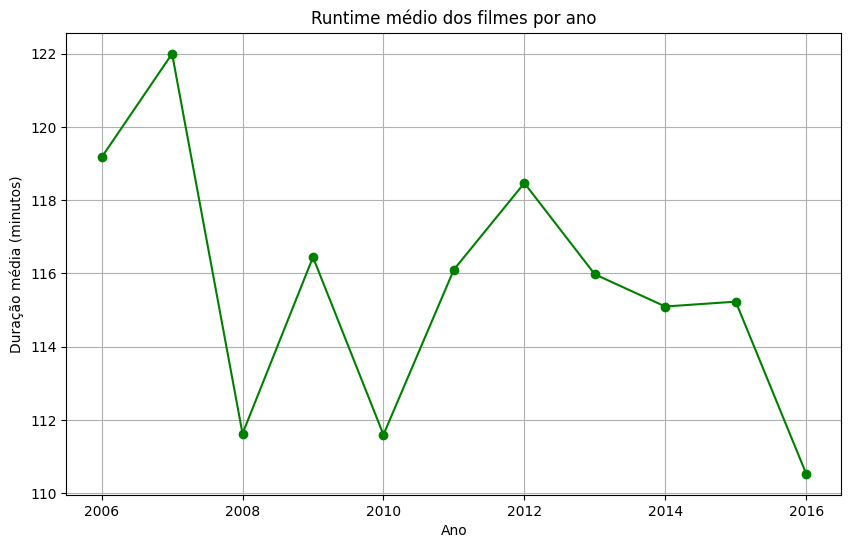

In [227]:
df["Runtime"] = pd.to_numeric(df["Runtime"], errors="coerce")
df = df.dropna()
df_year = df.groupby("Year")["Runtime"].mean().reset_index()
df_year = df_year.sort_values("Year")

plt.figure(figsize=(10,6))

plt.plot(df_year["Year"], df_year["Runtime"], marker="o", color="g")

plt.title("Runtime médio dos filmes por ano")
plt.xlabel("Ano")
plt.ylabel("Duração média (minutos)")

plt.grid(True)

plt.show()

